In [1]:
import idx2numpy
import numpy as np

np.random.seed(42)

with open("archive/t10k-images.idx3-ubyte", "rb") as f:
    test_images = idx2numpy.convert_from_file(f)

with open("archive/t10k-labels.idx1-ubyte", "rb") as f:
    test_labels = idx2numpy.convert_from_file(f)


# 1. Load raw files
train_images = idx2numpy.convert_from_file("archive/train-images.idx3-ubyte")
train_labels = idx2numpy.convert_from_file("archive/train-labels.idx1-ubyte")
train_images = train_images[:10001]
train_labels = train_labels[:10001]

# 2. Reshape to NCHW (N, 1, 28, 28) and scale to float32 [0.0, 1.0]
train_images = train_images[:, np.newaxis, :, :].astype(np.float32) / 255.0

# Helper function to generate mini-batches
def get_batches(X, y, batch_size=32, shuffle=True):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        batch_idx = indices[start_idx : start_idx + batch_size]
        yield X[batch_idx], y[batch_idx]

test_images = test_images[:, np.newaxis, :, :].astype(np.float32)/255.0
test_images = test_images[:10001]
test_labels = test_labels[:10001]

def evaluate_accuracy(model, test_images, test_labels, batch_size=64):
    # Temporarily disable graph tracking for inference
    previous_track_state = Nexus._track_graph
    Nexus._track_graph = False
    
    correct_predictions = 0
    total_samples = 0
    
    try:
        for bx_np, by_np in get_batches(test_images, test_labels, batch_size=batch_size):
            bx = Nexus(bx_np)
            
            # Forward pass
            logits = model.forward(bx)
            
            # Convert logits to class predictions (argmax across channel/class dimension)
            predictions = np.argmax(logits.value, axis=1)
            
            # Count correct matches
            correct_predictions += np.sum(predictions == by_np)
            total_samples += len(by_np)
            
    finally:
        # Restore autograd graph state
        Nexus._track_graph = previous_track_state
        
    accuracy = (correct_predictions / total_samples) * 100
    print(f"Test Accuracy: {accuracy:.2f}% ({correct_predictions}/{total_samples})")
    return accuracy



In [2]:
import sys
import numpy as np
from pathlib import Path

curr_dir = Path.cwd()
prj_root = curr_dir.parent.parent
sys.path.append(str(prj_root))

from core.model import Sequential
from core.Nexus import Nexus
from extensions.Layers import Conv2D, Linear, MaxPool2D, Flatten
from extensions.Activations import ReLU
from extensions.Optimizers import SGD, Adam
from extensions.Loss import CategoricalCrossEntropyLoss


In [3]:

model = Sequential(
    # (N, 1,28,28) -> (N,4,28,28)
    Conv2D(3, 1,4,1,1),
    # (N,4,28,28)
    ReLU(),
    # (N,4,14,14)
    MaxPool2D(2,2),
    # (N, 4*14*14)
    Flatten(),
    # (N, 10)
    Linear(4*14*14,10),
)

optim = Adam(model.parameters(), lr=0.0001)

In [4]:
epochs = 500
batch_size = 128
losses = []

num_classes = 10

for epoch in range(epochs):
    avg_loss=[]
    
    for bx_np, by_np in get_batches(train_images, train_labels, batch_size=batch_size):
        optim.zero_grad()

        # Wrap numpy batch into Nexus Node
        bx = Nexus(bx_np)
        by = Nexus(np.eye(num_classes)[by_np])
        # Forward Pass
        y_logits = model.forward(bx)

        # Compute Loss (expects raw logits and integer target indices)
        loss = CategoricalCrossEntropyLoss(by, y_logits)

        # Backward Pass & Update
        loss.backward()
        optim.step()

        avg_loss.append(loss.value.item())
        
    losses.append(np.mean(avg_loss))
    if epoch%50==0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {np.mean(avg_loss):.8f}")

model.export_weights("cnn_model")

Epoch 1/500 - Loss: 4.57816423
Epoch 51/500 - Loss: 1.61243012
Epoch 101/500 - Loss: 0.83716431
Epoch 151/500 - Loss: 0.57205512
Epoch 201/500 - Loss: 0.44264804
Epoch 251/500 - Loss: 0.37362207
Epoch 301/500 - Loss: 0.32732478
Epoch 351/500 - Loss: 0.29215204
Epoch 401/500 - Loss: 0.27131943
Epoch 451/500 - Loss: 0.24812646


In [5]:
test_acc = evaluate_accuracy(model, test_images, test_labels, batch_size=128)

Test Accuracy: 91.76% (9176/10000)


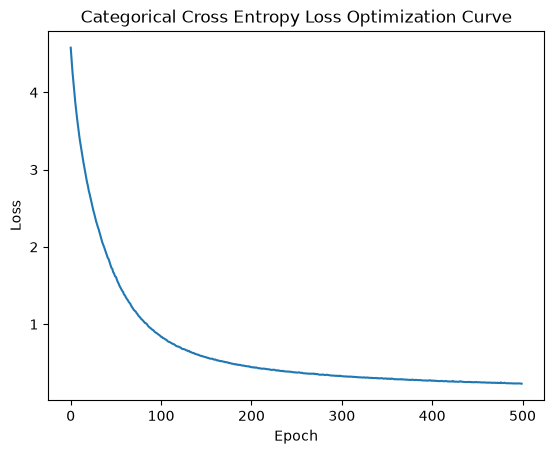

In [6]:
import matplotlib.pyplot as plt
plt.plot(range(epochs), losses)
plt.title("Categorical Cross Entropy Loss Optimization Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()